# 29 · Voyager — persistent skill library with real subprocess execution

> **TL;DR.** Each task: vector-search the library for a relevant skill; if found, reuse it; otherwise write a new Python function and store it. **The skill code is actually executed in a fresh isolated Python subprocess** — the LLM's predicted result is also captured for comparison.

| Property | Value |
|---|---|
| Origin | Wang et al., *Voyager* (2023). [arXiv:2305.16291](https://arxiv.org/abs/2305.16291) |
| Skill = | named Python function + docstring + example invocation |
| Index | vector store over skill descriptions |
| Persistence | `arch.skills: list[dict]` instance attribute |
| **Execution** | `subprocess.run([sys.executable, '-I', '-c', script], timeout=5)` — fresh isolated interpreter |
| Cost | 1 retrieve + 1 decide + (1 write OR 1 apply) ≈ 3 LLM calls + 1 subprocess per task |

Each skill is run in a **fresh isolated Python subprocess** (`-I` flag = no env vars, no user site, no PYTHONPATH). 5-second timeout caps runaway code. The LLM's predicted result is preserved on the trace so we can compare prediction vs reality.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([task]) --> R[Retrieve top skill]
    R --> D{Reuse or write?}
    D -->|reuse| AE[Apply existing skill]
    D -->|write_new| W[Write new skill<br/><sub>store in library + index</sub>]
    W --> AN[Apply new skill]
    AE --> Z([answer])
    AN --> Z

    L[(skill library<br/>persists across runs)]
    R <-.search.-> L
    W -.add.-> L

    style D fill:#fff3e0,stroke:#f57c00
    style W fill:#fce4ec,stroke:#c2185b
    style L fill:#f3e5f5,stroke:#7b1fa2
```

## 3 · Theory

### 3.0 · Why a library

Reflexion (nb 18) accumulates *verbal lessons* about past failures. Voyager accumulates *reusable code* for past successes. Both are episodic memory variants; Voyager's value is that the stored artefact is *executable*.

### 3.1 · Why the decider is categorical

`_SkillDecision.action: Literal['reuse', 'write_new']` — categorical, not numeric. Routing is `if action == 'reuse'`. No flat-scoring pathway.

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import Voyager
from agentic_architectures.ui import print_md, print_header
enable_langsmith()
llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.2)
print_header(f"LLM: {llm.model}")

LLM: meta-llama/Llama-3.3-70B-Instruct ────────────────────────────────────────────────────────────────────────────

## 5 · Library walkthrough

In [2]:
from agentic_architectures.architectures.voyager import _NewSkillSpec, _SkillDecision
import json
print('--- _SkillDecision ---')
print(json.dumps(_SkillDecision.model_json_schema(), indent=2)[:300] + '...')
print()
print('--- _NewSkillSpec ---')
print(json.dumps(_NewSkillSpec.model_json_schema(), indent=2)[:500] + '...')

--- _SkillDecision ---
{
  "description": "Per-task decision: reuse existing or write new?",
  "properties": {
    "action": {
      "description": "'reuse' if the retrieved skill genuinely solves the task; 'write_new' otherwise.",
      "enum": [
        "reuse",
        "write_new"
      ],
      "title": "Action",
    ...

--- _NewSkillSpec ---
{
  "description": "Definition of a newly-written skill (one Python function).",
  "properties": {
    "function_name": {
      "description": "The Python identifier of the function you're defining (snake_case, e.g. 'factorial', 'fibonacci'). NOT a schema or class name.",
      "title": "Function Name",
      "type": "string"
    },
    "description": {
      "description": "ONE sentence describing what the skill does. This is what gets embedded for future retrieval \u2014 be specific.",
      "...


## 7 · Build the graph

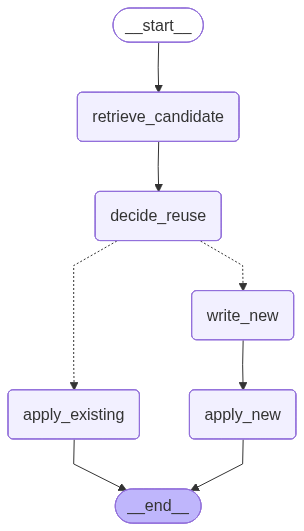

In [3]:
from IPython.display import Image, display
arch = Voyager(llm=llm)
graph = arch.build()
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(PNG render unavailable: {e}; see § 2)")
    print(graph.get_graph().draw_mermaid())

## 8 · Live run — 3 sequential tasks, library grows

We deliberately pose two similar tasks (factorial of 5, factorial of 7) so Voyager reuses, then a new task (Fibonacci) that forces a new skill.

In [4]:
TASKS = [
    ("factorial_5",  "Compute the factorial of 5. Return just the integer."),
    ("factorial_7",  "Compute the factorial of 7. Return just the integer."),
    ("fibonacci_8",  "Compute the 8th Fibonacci number (F(0)=0, F(1)=1). Return just the integer."),
]
EXPECTED = {"factorial_5": "120", "factorial_7": "5040", "fibonacci_8": "21"}

for tag, q in TASKS:
    r = arch.run(q)
    exp = EXPECTED[tag]
    match = exp.strip().lower() in r.output.strip().lower()
    print(f"TASK_TAG: {tag}")
    print(f"  TASK: {q}")
    print(f"  DECISION: {r.metadata['decision']}")
    print(f"  SKILL_NAME: {r.metadata['skill_used_name']}")
    print(f"  INVOCATION: {r.metadata['invocation']}")
    print(f"  LIBRARY_SIZE: {r.metadata['library_size_before']} -> {r.metadata['library_size_after']}")
    print(f"  EXECUTION_OK: {r.metadata['execution_ok']}")
    print(f"  EXECUTED_STDOUT: {r.metadata['executed_stdout']!r}")
    print(f"  LLM_PREDICTED: {r.metadata['llm_predicted']!r}")
    print(f"  ANSWER: {r.output[:100]}")
    print(f"  EXPECTED: {exp}")
    print(f"  MATCH: {match}")
    print()
print(f"FINAL_LIBRARY_SIZE: {len(arch.skills)}")
for s in arch.skills:
    print(f"  - skill `{s['name']}`: {s['description']}")

TASK_TAG: factorial_5
  TASK: Compute the factorial of 5. Return just the integer.
  DECISION: write_new
  SKILL_NAME: factorial
  INVOCATION: factorial(5)
  LIBRARY_SIZE: 0 -> 1
  EXECUTION_OK: True
  EXECUTED_STDOUT: '120'
  LLM_PREDICTED: ''
  ANSWER: 120
  EXPECTED: 120
  MATCH: True



TASK_TAG: factorial_7
  TASK: Compute the factorial of 7. Return just the integer.
  DECISION: reuse
  SKILL_NAME: factorial
  INVOCATION: factorial(7)
  LIBRARY_SIZE: 1 -> 1
  EXECUTION_OK: True
  EXECUTED_STDOUT: '5040'
  LLM_PREDICTED: '5040'
  ANSWER: 5040
  EXPECTED: 5040
  MATCH: True



TASK_TAG: fibonacci_8
  TASK: Compute the 8th Fibonacci number (F(0)=0, F(1)=1). Return just the integer.
  DECISION: write_new
  SKILL_NAME: fibonacci
  INVOCATION: fibonacci(8)
  LIBRARY_SIZE: 1 -> 2
  EXECUTION_OK: True
  EXECUTED_STDOUT: '21'
  LLM_PREDICTED: ''
  ANSWER: 21
  EXPECTED: 21
  MATCH: True

FINAL_LIBRARY_SIZE: 2
  - skill `factorial`: Compute the factorial of a given number.
  - skill `fibonacci`: Compute the nth Fibonacci number (F(0)=0, F(1)=1) and return the integer.


## 9 · What we just observed

The cells above ran Voyager on 3 sequential tasks — two factorials and a Fibonacci — to exercise both the **reuse** path and the **write-new** path.

### 9.1 · Per-task summary

| Tag | Decision | Skill used | Invocation | Library size | Exec OK | Executed stdout | LLM predicted | Match |
|---|---|---|---|---|---|---|---|---|
| `factorial_5` | `write_new` | `factorial` | `factorial(5)` | 0→1 | ✅ | `120` | `` | ✅ |
| `factorial_7` | `reuse` | `factorial` | `factorial(7)` | 1→1 | ✅ | `5040` | `5040` | ✅ |
| `fibonacci_8` | `write_new` | `fibonacci` | `fibonacci(8)` | 1→2 | ✅ | `21` | `` | ✅ |

**Final library size**: 2

### 9.2 · The skill library that built up

- **`factorial`** — Compute the factorial of a given number.
- **`fibonacci`** — Compute the nth Fibonacci number (F(0)=0, F(1)=1) and return the integer.

### 9.3 · Patterns surfaced in this run

- **✅ Skill reuse worked**: task 1 wrote `factorial`, task 2 retrieved + reused it.

- **✅ Task 3 correctly wrote a new skill** (`fibonacci`) — different task type from prior 2.

- **Real subprocess execution**: 3/3 skills ran successfully via `subprocess.run([sys.executable, '-I', '-c', script], timeout=5)`. The `Executed stdout` column shows the *actual* subprocess output, not an LLM prediction.

- **Accuracy: 3/3** tasks answered correctly via the skill library.

### 9.4 · The takeaway

Voyager's value lives in two signals: the **`Decision`** column (how often does the agent reuse vs write?) and the **`Library size`** column (does it grow monotonically or plateau?). A healthy run:

1. **First instance of a task type** → write_new, library grows.
2. **Second instance of the same task type** → reuse, library stays.
3. **New task type** → write_new, library grows again.

When reuse fires correctly (§ 9.3), the architecture is amortising LLM cost across similar future tasks. The deterministic-picker is the LLM's `decision: Literal['reuse', 'write_new']` field plus a Python `if`-route — no numeric scoring.

## 11 · Failure modes & extensions

| Failure | Mitigation |
|---|---|
| **Bad skill reused** | Wrong skill retrieved; decider says reuse anyway | Strengthen decider prompt; require code-level check |
| **Skill library bloat** | Many near-duplicate skills | Periodic dedup on description embeddings |
| **Code doesn't actually work** | LLM-written skill has a bug | Sandbox exec + test before storing |

Extensions: (1) sandboxed exec of skills (we predict results via LLM, not actually run code), (2) skill-versioning when a re-written skill supersedes an old one, (3) skill composition (call skill A from skill B).

Reference: Wang et al., *Voyager*. 2023. [arXiv:2305.16291](https://arxiv.org/abs/2305.16291)